# Does C4-equivariance cost the XY classifier any accuracy, and where?

This notebook produces `Plots/model_error_percent_val_equivariance.pdf`
(Fig. 18, App. F 3 "Rotationally invariant and unconstrained
TetrisCNN"). It is a cut-down variation on
`FiguresApp_F_error_rates.ipynb`: that notebook stacks an Ising panel over a
three-basis XY panel, this one keeps **only the bottom kind of panel** and repurposes
it for one question:

> Does constraining the convolutional branches to be **C4-equivariant** change how well
> the network classifies the XY $XZ$ partition, time point by time point?

Two series on one axes, overlaid, each a **mean ± std over 5 seeds** (42-46), not a
single seed's point estimate:

- **equivariant** -- `Paris_XY_XZ`, $\lambda_{\max}$ index 3, `partition_2`,
  C4-equivariant branches (5 nested Tetris kernels, weights tied across each C4 orbit);
- **plain** -- same dataset / $\lambda_{\max}$ / partition, branches *not* tied
  (10 kernels, one per orientation).

$\lambda_{\max}$ index 3 is the choice every XY panel in `FiguresApp_F_error_rates.ipynb`
already plots. Nothing is fitted here: the bars are the trained model's prediction
against the ground-truth partition label, resolved per time point.

### Why this matters

The main text (Sec. II C, Eq. (6)) builds TetrisCNN with branches tied
across the square lattice's $C_4$ rotations, since a smaller, weight-tied bottleneck is
easier to read off physically. The appendix this figure supports (`app:rotational_invariance`)
checks what that constraint costs: the unconstrained network turns out to classify the
XY transition about one percentage point more accurately overall, and this figure shows
that gap is not spread evenly across the sweep but concentrated near the transition
itself, indicating the raw snapshots carry a little classification-relevant structure
that is not rotationally invariant.

### What it reads

Ten trained runs under `Plots_data/XY_XZ_{C4,plain}_smallkernels_lam3_seed{42..46}_p2/`
(5 equivariant + 5 plain seeds), each a full `config.json`/`net1.pt`/`net2.pt` checkpoint
on the native, unmatched $XZ$ acquisition grid; the model-selector cells below name the
exact paths.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE

from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from tetriscnn.datasets import create_datasets
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import AttrDict, DEVICE, load_json

from tetriscnn.colors import COLORS

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Configuration

`SPLIT` is the one global choice with teeth: nothing here is *fitted*, but `"val"` is
still the honest default. `Y_MODE` picks what the bars measure -- the per-time-point
error **rate** (`"percent"` / `"fraction"`) or the raw misclassified **count**. Both
series share the same dataset/task, and `create_datasets()` seeds its train/val split
independently of `cf.seed`, so every one of the 10 runs (5 equivariant + 5 plain) sits
on the *same* split with the *same* per-time-point sample counts -- the only thing
differing between and within the two series is the trained weights (architecture and
seed respectively).

In [2]:
SPLIT = "val"            # "val" (held out) or "train"
Y_MODE = "percent"       # "percent" | "fraction" | "count"

OUTDIR = Path("Plots")
OUTDIR.mkdir(exist_ok=True)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
GOLDEN = (1 + np.sqrt(5)) / 2

try:
    plt.style.use(PAPER_MPLSTYLE)
except Exception as exc:                       # LaTeX not reachable from this kernel
    print(f"paper.mplstyle unavailable ({exc}); falling back to mathtext")
    plt.rcParams["text.usetex"] = False

## Model selectors

One cell per series. Each names a **run-folder template** (`path_template`, with a
`{seed}` placeholder) plus the `seeds` tuple it is evaluated over, since every bar in
this notebook is a mean ± std across 5 seeds, not one run. Both point at the
non-matched `Paris_XY_XZ` runs in `Plots_data/`: the snapshot-count-matched runs the
companion notebook uses exist only for the C4 *cross-basis* survey (X vs Z vs XZ), so
there is no matched `plain` run to compare against. The equivariance ablation was
trained on XZ's native 13-point grid. Same $\lambda_{\max}$ index (3), same 5 seeds,
same `partition_2` / 625 ns threshold for both, so the architecture is the only moving
part.

In [3]:
# --- equivariant: C4-tied Tetris branches -----------------------------------------
EQUIVARIANT = dict(
    label="invariant "+r"$(C_4)$",
    path_template=Path("Plots_data/XY_XZ_C4_smallkernels_lam3_seed{seed}_p2"),
    seeds=(42, 43, 44, 45, 46),
    run_template="lambdamax_3/seed_{seed}/partition_2",
)

In [4]:
# --- plain: untied branches, one per orientation --------------------------------
PLAIN = dict(
    label="unconstrained",
    path_template=Path("Plots_data/XY_XZ_plain_smallkernels_lam3_seed{seed}_p2"),
    seeds=(42, 43, 44, 45, 46),
    run_template="lambdamax_3/seed_{seed}/partition_2",
)

In [5]:
# MODELS order == the draw-order argument the panel receives (equivariant first).
MODELS = OrderedDict([("equivariant", EQUIVARIANT), ("plain", PLAIN)])


def seed_path(m, seed):
    """The run folder for one seed of model dict `m`."""
    return Path(str(m["path_template"]).format(seed=seed))


missing = []
for key, m in MODELS.items():
    for s in m["seeds"]:
        p = seed_path(m, s)
        ok = (p / "net1.pt").exists()
        print(f"{key:>12} seed_{s}  {'OK ' if ok else 'MISSING'}  {p}")
        if not ok:
            missing.append((key, s))

if missing:
    raise FileNotFoundError(f"no net1.pt for: {missing}")

 equivariant seed_42  OK   Plots_data/XY_XZ_C4_smallkernels_lam3_seed42_p2
 equivariant seed_43  OK   Plots_data/XY_XZ_C4_smallkernels_lam3_seed43_p2
 equivariant seed_44  OK   Plots_data/XY_XZ_C4_smallkernels_lam3_seed44_p2
 equivariant seed_45  OK   Plots_data/XY_XZ_C4_smallkernels_lam3_seed45_p2
 equivariant seed_46  OK   Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2
       plain seed_42  OK   Plots_data/XY_XZ_plain_smallkernels_lam3_seed42_p2
       plain seed_43  OK   Plots_data/XY_XZ_plain_smallkernels_lam3_seed43_p2
       plain seed_44  OK   Plots_data/XY_XZ_plain_smallkernels_lam3_seed44_p2
       plain seed_45  OK   Plots_data/XY_XZ_plain_smallkernels_lam3_seed45_p2
       plain seed_46  OK   Plots_data/XY_XZ_plain_smallkernels_lam3_seed46_p2


## Load the runs

`load_run` is `FiguresApp_F_error_rates.ipynb`'s loader, unchanged: config + weights from
a run folder, one split pushed through the net in a single `shuffle=False` batch so
predictions, truth and times align index-for-index. It also returns `y_true`, the
ground-truth class (`argmax` of the one-hot partition label), which is constant within a
time point and is what makes a per-time-point error rate well defined.

`load_run_seeds` calls it once per seed of a model, so `DATA[key]` below is a **list of
5 per-seed result dicts**.

In [6]:
def load_run(run_folder: Path, split: str = "val"):
    """Config + weights from a run folder, with one split pushed through the net."""
    cf = AttrDict()
    cf.update(load_json(str(run_folder), "config.json"))

    # Legacy runs recorded kernels without a stride entry.
    for k in range(len(cf.kernels)):
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)

    # Point the config at where it was LOADED from, not where it was first saved.
    cf.logdir = cf.seed_folder = str(run_folder)
    cf.return_all_data = False

    train_ds, val_ds = create_datasets(cf)
    dataset = {"train": train_ds, "val": val_ds}[split]

    net1 = ShapeAdaptiveConvNet(
        in_channels=dataset[0][0].shape[0],
        kernels=cf.kernels,
        equivariant=cf.equivariant,
        hidden_size=cf.hidden_size,
        init=cf.init,
        device=DEVICE,
    ).to(DEVICE)
    net2 = SmallModel(
        [len(cf.kernels), 32, 16, dataset.output_dim], device=DEVICE
    ).to(DEVICE)
    net1.load_state_dict(torch.load(run_folder / "net1.pt", map_location=DEVICE))
    net2.load_state_dict(torch.load(run_folder / "net2.pt", map_location=DEVICE))
    net1.eval()
    net2.eval()

    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            z = net1(x)
            out = net2(z)

    labels = dataset.labels.detach().cpu().numpy()
    if labels.ndim != 2 or labels.shape[1] < 2:
        raise ValueError(
            f"{run_folder}: expected one-hot labels from a discrete-label task, got "
            f"shape {labels.shape} (task={cf.task}). This notebook scores CLASSES.")

    return {
        "cf": cf, "path": run_folder, "split": split,
        "z": z.cpu().numpy(), "out": out.cpu().numpy(),
        "y_pred": out.cpu().numpy().argmax(axis=1),
        "y_true": labels.argmax(axis=1),
        "times": dataset.times.detach().cpu().numpy(),
    }

In [7]:
def load_run_seeds(m, split):
    """load_run() for every seed of model dict `m`, in seed order."""
    return [load_run(seed_path(m, s), split) for s in m["seeds"]]

In [8]:
DATA = {}
for key, m in MODELS.items():
    DATA[key] = load_run_seeds(m, SPLIT)
    accs = np.array([float((d["y_pred"] == d["y_true"]).mean()) for d in DATA[key]])
    d0 = DATA[key][0]
    print(f"{key:>12}  {d0['cf'].dataset:<12} eq={str(d0['cf'].equivariant):<5} "
          f"branches={len(d0['cf'].kernels):>2}  part={d0['cf'].partition_index} "
          f"lam={d0['cf'].lam}  n={len(d0['y_true']):>5}  "
          f"times={len(np.unique(d0['times'])):>3}  "
          f"acc={accs.mean():.4f}+-{accs.std(ddof=1):.4f}  "
          f"err={1 - accs.mean():.4f}+-{accs.std(ddof=1):.4f}  (5 seeds)")

# All 10 runs (5 equivariant + 5 plain) share one dataset/task, so they should all sit
# on the exact same split. The overlay's honesty depends on that, so assert it rather
# than trust it.
all_times_sorted = [np.sort(d["times"]) for dlist in DATA.values() for d in dlist]
assert all(np.array_equal(all_times_sorted[0], t) for t in all_times_sorted[1:]), (
    "not every run's time array matches; the overlay would not compare like with like")


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])



Using C4-equivariant convolutional branches.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using C4-equivariant convolutional branches.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using C4-equivariant convolutional branches.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using C4-equivariant convolutional branches.


...


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.


       plain  Paris_XY_XZ  eq=False branches=10  part=2 lam=3  n= 4347  times= 13  acc=0.9442+-0.0058  err=0.0558+-0.0058  (5 seeds)


## Error rate by time point

`error_by_time` is the per-seed measurement: the mean of a boolean per-sample flag,
grouped by time. `error_stats_by_time` then takes the **mean and std across the 5
seeds** of one series, time point by time point -- valid because every run (both
series, all seeds) shares the exact same train/val split (verified above). A time
point with no samples in this split returns `nan` (a missing bar and a bar of height
zero mean opposite things). The two series share a grid here, but the panel is still
indexed by the union of the two, so a time point that survives into one and not the
other stays visible.

In [9]:
def error_by_time(d, all_times):
    """Per-time-point misclassification rate for ONE seed; nan where the split has no samples."""
    t, wrong = d["times"], d["y_pred"] != d["y_true"]
    return np.array([wrong[t == tt].mean() if np.any(t == tt) else np.nan
                     for tt in all_times])


def counts_by_time(d, all_times):
    t = d["times"]
    return np.array([int((t == tt).sum()) for tt in all_times])


def error_stats_by_time(dlist, all_times):
    """Mean +/- std of the per-time-point error rate ACROSS SEEDS (see the shared-split
    assertion in the loading cell for why this is valid)."""
    mat = np.stack([error_by_time(d, all_times) for d in dlist])   # (n_seeds, n_times)
    return np.nanmean(mat, axis=0), np.nanstd(mat, axis=0, ddof=1)


TIMES = {k: np.array(sorted(np.unique(DATA[k][0]["times"]))) for k in MODELS}
ALL_TIMES = np.array(sorted(set().union(*(set(TIMES[k].tolist()) for k in MODELS))))

for k in MODELS:
    extra = len(ALL_TIMES) - len(TIMES[k])
    print(f"{k:>12}: {len(TIMES[k]):>3} time points"
          + (f"  ({extra} of the union's {len(ALL_TIMES)} missing)" if extra else
             "  (== the union)"))

ERR, ERR_SD, CNT = {}, {}, {}
for k in MODELS:
    ERR[k], ERR_SD[k] = error_stats_by_time(DATA[k], ALL_TIMES)
    CNT[k] = counts_by_time(DATA[k][0], ALL_TIMES)

 equivariant:  13 time points  (== the union)
       plain:  13 time points  (== the union)


In [10]:
# The numbers behind the figure, so any bar (and its error bar) can be read off exactly.
# `n` is shared by every run (same split); `err`/`errsd` are the mean/std of the
# per-seed error rate; `nerr` is the integer error count the mean rate implies.
# `d(eq-plain)` is the gap the panel shows.
def rate_table(keys, all_times):
    tbl = pd.DataFrame({r"$t$ (us)": all_times / 1000})
    tbl["n"] = CNT[keys[0]]
    for k in keys:
        tbl[f"err_{k}"] = ERR[k]
        tbl[f"errsd_{k}"] = ERR_SD[k]
        tbl[f"nerr_{k}"] = np.rint(np.nan_to_num(ERR[k]) * CNT[k]).astype(int)
    tbl["d(eq-plain)"] = tbl["err_equivariant"] - tbl["err_plain"]
    return tbl.set_index(r"$t$ (us)")


display(rate_table(list(MODELS), ALL_TIMES).round(4))

# Totals must reproduce the (mean-over-seeds) accuracies printed at load time.
print(f"\n{'model':>12}{'errors':>9}{'n':>8}{'rate':>9}{'1-acc(mean)':>13}")
for k in MODELS:
    e, n = ERR[k], CNT[k]
    ok = ~np.isnan(e)
    n_err = int(round(float((e[ok] * n[ok]).sum())))
    accs = np.array([float((d["y_pred"] == d["y_true"]).mean()) for d in DATA[k]])
    print(f"{k:>12}{n_err:>9}{int(n.sum()):>8}{n_err / n.sum():>9.4f}{1 - accs.mean():>13.4f}")

,n,err_equivariant,errsd_equivariant,nerr_equivariant,err_plain,errsd_plain,nerr_plain,d(eq-plain)
$t$ (us),,,,,,,,
0.00,534,0.0419,0.0010,22,0.0337,0.0032,18,0.0082
0.25,528,0.0557,0.0017,29,0.0345,0.0099,18,0.0212
0.50,526,0.2817,0.0028,148,0.2464,0.0222,130,0.0354
0.75,317,0.0751,0.0026,24,0.0890,0.0088,28,-0.0139
1.00,300,0.0267,0.0000,8,0.0273,0.0037,8,-0.0007
1.25,299,0.0207,0.0015,6,0.0214,0.0051,6,-0.0007
1.50,253,0.0364,0.0018,9,0.0269,0.0052,7,0.0095
1.75,140,0.0143,0.0000,2,0.0029,0.0064,0,0.0114
2.00,773,0.0233,0.0022,18,0.0160,0.0056,12,0.0072



       model   errors       n     rate  1-acc(mean)
 equivariant      284    4347   0.0653       0.0654
       plain      243    4347   0.0559       0.0558


## The figure

One panel, the two series overlaid. With three series `FiguresApp_F_error_rates.ipynb`
had to dodge the bars; with two, overlaying works. `_draw_overlay` picks **fixed
semantic order** (option 2 of the four in its docstring): `plain` always drawn behind,
`equivariant` always drawn in front, so the reader tracks one series as "front" across
every time point rather than the front/back role flipping with whichever happens to be
taller. The cost is that `plain` is invisible wherever it is the taller of the two,
tracked and reported via `hidden` rather than left for the reader to notice.

Every bar also carries a thin error bar (± std over the 5 seeds).

  note: invariant $(C_4)$ exceeds unconstrained at 9 time point(s), where the unconstrained bar is hidden behind it


wrote Plots/model_error_percent_val_equivariance.pdf


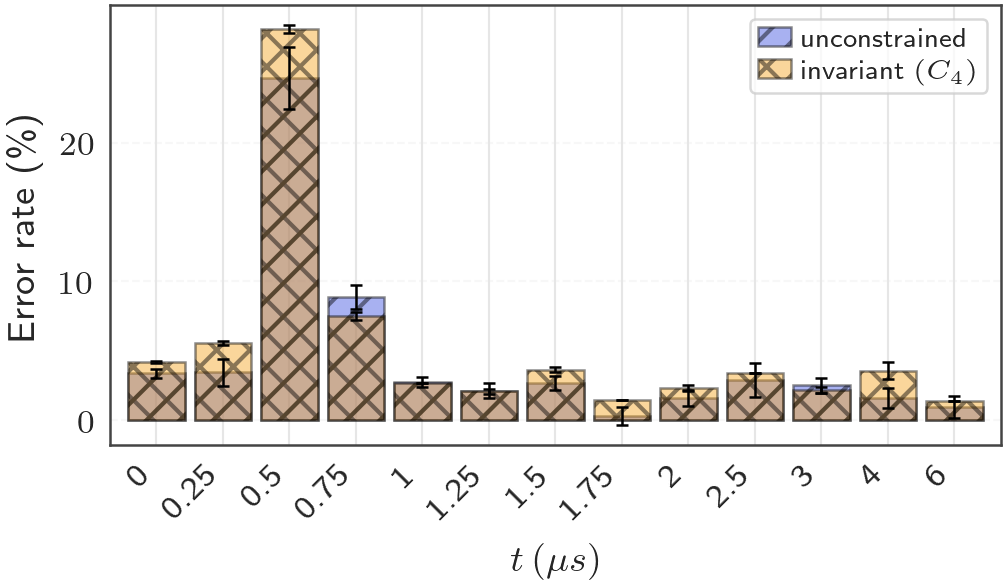

In [11]:
# One style per series. Hatches keep the panel readable in greyscale and where the two
# bars nearly coincide. Tweak to taste.
STYLE = {
    "equivariant": dict(color=COLORS["orange"], edgecolor="black", hatch="xxx"),
    "plain":       dict(color=COLORS["blue"], edgecolor="black", hatch="///"),
}

# Error-bar look, shared by every bar drawn below.
EBAR_KW = dict(elinewidth=0.6, capsize=1.5, capthick=0.6, ecolor="black")

# "%" is a comment char under usetex, so escape there and NOT under the mathtext fallback.
_PCT = r"\%" if plt.rcParams["text.usetex"] else "%"
Y_LABEL = {"percent": rf"Error rate ({_PCT})",
           "fraction": "Error rate",
           "count": "Errors"}


def series(k, mode):
    """One series' mean bar heights. `nan` (no samples at that time) becomes 0 for drawing."""
    e = np.nan_to_num(ERR[k])
    return {"percent": 100 * e, "fraction": e, "count": e * CNT[k]}[mode]


def series_err(k, mode):
    """The +/- std-across-5-seeds error bar for one series, in `series()`'s units."""
    e = np.nan_to_num(ERR_SD[k])
    return {"percent": 100 * e, "fraction": e, "count": e * CNT[k]}[mode]


def _draw_overlay(ax, keys, all_times, mode):
    """Draw the two error-rate series on `ax`, overlaid, and report what got hidden.

    keys    : [equivariant_key, plain_key], in MODELS order.
    returns : (x, hidden) where x = np.arange(len(all_times)) and `hidden` is a list of
              (front_label, back_label, n_timepoints) tuples -- bars the caller should
              mention in text because they sit behind a taller bar of the other series.

    DESIGN DECISION: fixed semantic order (option 2 of the four listed below).
    `plain` is always drawn first (behind), `equivariant` always second (in front), so
    the reader tracks one series as "front" across every time point instead of the
    front/back role flipping with whichever happens to be taller at a given t. The
    trade-off is that `plain`'s bar is fully invisible wherever it is the taller of the
    two -- counted into `hidden` below rather than left for the reader to discover.

    The three alternatives, for context:
      1. global z-order, tallest-total behind -- what FiguresApp_F_error_rates does for
         its 3-series panel.
      3. per-time-point order: draw the locally taller bar first at each t, so neither
         series is ever fully occluded (a short per-column loop, not one ax.bar call).
      4. one series unfilled (facecolor "none", thick edge) over the other filled:
         overlap is always legible and z-order stops mattering.
    """
    x = np.arange(len(all_times))
    hidden = []
    front_key, back_key = keys[0], keys[1]     # MODELS order: equivariant, plain

    ax.bar(x, series(back_key, mode), 0.85, yerr=series_err(back_key, mode),
           error_kw=EBAR_KW, label=MODELS[back_key]["label"], **STYLE[back_key],
           alpha=0.45)
    ax.bar(x, series(front_key, mode), 0.85, yerr=series_err(front_key, mode),
           error_kw=EBAR_KW, label=MODELS[front_key]["label"], **STYLE[front_key],
           alpha=0.45)

    n_hidden = int((series(back_key, mode) <= series(front_key, mode) + 1e-12).sum())
    if n_hidden:
        hidden.append((MODELS[front_key]["label"], MODELS[back_key]["label"], n_hidden))

    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_xlim(-0.7, len(all_times) - 0.3)
    return x, hidden


def _ticks(ax, x, all_times, max_labels=16):
    """Label every nth bar so a dense grid does not smear into itself."""
    every = max(1, int(np.ceil(len(all_times) / max_labels)))
    ax.set_xticks(x, minor=every > 1)
    if every > 1:
        ax.set_xticks(x[::every])
    ax.set_xticklabels([f"{t / 1000:g}" for t in all_times[::every]],
                       rotation=45, ha="right")


def plot_error_rates(mode=None, save=True):
    mode = Y_MODE if mode is None else mode
    if mode not in Y_LABEL:
        raise ValueError(f"mode must be one of {sorted(Y_LABEL)}, got {mode!r}")

    fig, ax = plt.subplots(figsize=(SINGLE_WIDTH, 0.95 * SINGLE_WIDTH / GOLDEN))

    x, hidden = _draw_overlay(ax, list(MODELS), ALL_TIMES, mode)
    ax.set_ylabel(Y_LABEL[mode])
    ax.set_xlabel(r"$t\,(\mu s)$")
    _ticks(ax, x, ALL_TIMES)
    ax.legend(fontsize=6.5, handletextpad=0.4, borderpad=0.3, loc="upper right")

    # The count panel must sum to each series' mean total error count; a tolerance
    # rather than exact equality since that mean is itself an average of 5 integers.
    if mode == "count":
        for k in MODELS:
            drawn = float(series(k, "count").sum())
            actual_mean = float(np.mean(
                [int((d["y_pred"] != d["y_true"]).sum()) for d in DATA[k]]))
            assert abs(drawn - actual_mean) < 1.0, (
                f"{k}: bars sum to {drawn}, mean model errors {actual_mean}")

    for front, back, n in hidden:
        print(f"  note: {front} exceeds {back} at {n} time point(s), where the "
              f"{back} bar is hidden behind it")

    if save:
        out = OUTDIR / f"model_error_{mode}_{SPLIT}_equivariance.pdf"
        fig.savefig(out, bbox_inches="tight")
        print(f"wrote {out}")
    return fig, ax


fig, ax = plot_error_rates()
plt.show()

## Provenance

Everything quotable from the figure, traced back to the runs that produced it: every
one of the 5 seeds behind each series, plus the mean ± std that series actually shows.

In [12]:
print(f"split       : {SPLIT}")
print(f"y mode      : {Y_MODE}\n")

hdr = (f"{'series':>12} {'dataset':>12} {'eq':>6} {'grp':>4} {'branches':>9} "
       f"{'lam':>4} {'part':>5} {'seed':>5} {'n':>7} {'err':>8}  run")
print(hdr); print("-" * len(hdr))
for k, m in MODELS.items():
    errs = []
    for s, d in zip(m["seeds"], DATA[k]):
        cf = d["cf"]
        err = float((d["y_pred"] != d["y_true"]).mean())
        errs.append(err)
        grp = getattr(cf, "equivariant_group", "-")
        print(f"{k:>12} {cf.dataset:>12} {str(cf.equivariant):>6} {str(grp):>4} "
              f"{len(cf.kernels):>9} {cf.lam:>4} {cf.partition_index:>5} "
              f"{s:>5} {len(d['y_true']):>7} {err:>8.4f}  {seed_path(m, s)}")
    errs = np.array(errs)
    print(f"{k:>12} {'':>12} {'':>6} {'':>4} {'':>9} {'':>4} {'':>5} {'mean':>5} "
          f"{'':>7} {errs.mean():>8.4f}  +/- {errs.std(ddof=1):.4f}  (5 seeds)")

split       : val
y mode      : percent

      series      dataset     eq  grp  branches  lam  part  seed       n      err  run
--------------------------------------------------------------------------------------
 equivariant  Paris_XY_XZ   True   C4         5    3     2    42    4347   0.0651  Plots_data/XY_XZ_C4_smallkernels_lam3_seed42_p2
 equivariant  Paris_XY_XZ   True   C4         5    3     2    43    4347   0.0649  Plots_data/XY_XZ_C4_smallkernels_lam3_seed43_p2
 equivariant  Paris_XY_XZ   True   C4         5    3     2    44    4347   0.0672  Plots_data/XY_XZ_C4_smallkernels_lam3_seed44_p2
 equivariant  Paris_XY_XZ   True   C4         5    3     2    45    4347   0.0653  Plots_data/XY_XZ_C4_smallkernels_lam3_seed45_p2
 equivariant  Paris_XY_XZ   True   C4         5    3     2    46    4347   0.0646  Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2
 equivariant                                                mean           0.0654  +/- 0.0010  (5 seeds)
       plain  Paris_XY_XZ